# Exploring Chemical Space
Explore some clustering and visualisation models and compare them for two different datasets:
- A subset of ChEMBL small molecule entries with a molecular weight between 200 and 500. Since the entire set of ChEMBL entries is quite substantial, 10k entries were selected by random sampling (`chembl_200-500_10k`)
- The result of the PubChem search for "antibiotics" (`pubchem_antibiotics`).

Note: The ChEMBL dataset may still take quite some processing time - depending on your PC. You can do a random sampling of e.g. 3k entries in order to reduce the computational effort.

Tasks:
1) Load and inspect the two datasets `ChEMBL_200-500_10k.csv`. Note that they are fundamentally different.
2) Perform basic data cleaning and be mindful of which data to dismiss (if any). Hint: Think about standardising column names (at least for the relevant ones)
3) Make sure that the SMILES strings are valid - implement a function to clean up the SMILES returning (in a new column or Series) the canonical SMILES if the input is valid, and return `None` if the SMILES in the original data is not valid (). Hint: The `Normalizer` in  rdkit might be quite useful (https://www.rdkit.org/docs/cppapi/classRDKit_1_1MolStandardize_1_1Normalizer.html)
4) Calculate Morgan Fingerprints (radius 2, 2048 bit) from the SMILES strings via mol objects. Make sure not to use the outdated version. You can use either the dataframe, numpy arrays or simple lists for the fingerprints.
5) Run different clustering techniques, e.g. snippets provided for Butina and HDBSCAN. You can also try the scikit-learn models kmeans or dbscan.
6) Use the fingerprints to run UMAP and TSNE dimensionality reductions (snippets provided).
7) Plot the data in scatterplots, using the cluster labels as colour map.
8) Adjust some parameters of the clustering models and apply filters if needed (e.g. only visualise clusters of a size larger than 10) to reach some satisfactory result
9) Visualise a representative molecule (e.g. centroids or centers of clusters, or random :) ) of the three largest clusters for both methods using rdkit
10) Respond to the discussion points


Import dependencies and datasets

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import hdbscan
import umap

from rdkit import Chem
from rdkit.Chem.MolStandardize.rdMolStandardize import Normalizer
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE

c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\hdbscan\robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


In [6]:
def process_dataset(filepath):
    df = pd.read_csv(filepath)
    df.columns = [c.lower() for c in df.columns]
    
    smiles_col = [col for col in df.columns if 'smiles' in col][0]
    df = df.rename(columns={smiles_col: 'smiles'})
    
    df = df.dropna(subset=['smiles']).reset_index(drop=True)
    return df

df_chembl = process_dataset('chembl_200-500_10k.csv')
df_pubchem = process_dataset('pubchem_antibiotics.csv')

print(f"ChEMBL records: {len(df_chembl)} | PubChem records: {len(df_pubchem)}")

ChEMBL records: 9993 | PubChem records: 2358


Calculate Morgan Fingerprints (`GetMorganGenerator`). You can experiment with other fingerprints (`GetRDKitFPGenerator`) as well and see how they impact the clusters.

In [ ]:
normalizer = Normalizer()

def clean_smiles(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            norm_mol = normalizer.normalize(mol)
            return Chem.MolToSmiles(norm_mol, canonical=True)
        return None
    except:
        return None

df_chembl['clean_smiles'] = df_chembl['smiles'].apply(clean_smiles)
df_pubchem['clean_smiles'] = df_pubchem['smiles'].apply(clean_smiles)

df_chembl = df_chembl.dropna(subset=['clean_smiles']).reset_index(drop=True)
df_pubchem = df_pubchem.dropna(subset=['clean_smiles']).reset_index(drop=True)

[17:14:30] Initializing Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:14:30] Running Normalizer
[17:1

In [16]:
df_chembl["fingerprint"] = df_chembl['clean_smiles'].apply(lambda s: rdFingerprintGenerator.GetRDKitFPGenerator().GetFingerprint(Chem.MolFromSmiles(s)))
df_pubchem["fingerprint"] = df_pubchem['clean_smiles'].apply(lambda s: rdFingerprintGenerator.GetRDKitFPGenerator().GetFingerprint(Chem.MolFromSmiles(s)))

[17:16:40] WARNING: not removing hydrogen atom without neighbors
[17:16:40] WARNING: not removing hydrogen atom without neighbors
[17:16:41] WARNING: not removing hydrogen atom without neighbors
[17:16:41] WARNING: not removing hydrogen atom without neighbors
[17:16:41] WARNING: not removing hydrogen atom without neighbors
[17:16:41] WARNING: not removing hydrogen atom without neighbors
[17:16:41] WARNING: not removing hydrogen atom without neighbors


Butina Clustering: Investigate later how different cutoffs for the similarity affect the clusters.

In [18]:
# Butina clustering requires distance matrix (distance = Tanimoto similarity); 
# fingerprints provided as list in this snippet - adjust as needed!
fp_list = df_pubchem['fingerprint'].tolist()
dists = []
nfps = len(fp_list)

for i in range(1, nfps):
    similarities = DataStructs.BulkTanimotoSimilarity(fp_list[i], fp_list[:i])
    dists.extend([1-x for x in similarities])

# Apply Butina Clustering

# Apply different thresholds later and see how they affect the clustering
cutoff = 0.6  # Tanimoto similarity threshold; e.g. 04 for larger chemical families, 0.7 for tight analogues...

butina_clusters = Butina.ClusterData(
    dists, # similarity based distance matrix
    nfps, # number of fingerprints
    cutoff,
    isDistData=True
)

print("Number of clusters:", len(butina_clusters))

Number of clusters: 150


In [19]:
# filter out small clusters, rare chemoptypes, ...
clusters_filtered = [c for c in butina_clusters if len(c) >= 10]

butina_labels = np.full(nfps, -1)
for cluster_id, cluster in enumerate(clusters_filtered):
    for id in cluster:
        butina_labels[id] = cluster_id

sizes = [len(c) for c in clusters_filtered]

print("clusters:", len(sizes))
print("mean size:", np.mean(sizes))
print("max size:", np.max(sizes))
print("singletons:", sum(s == 1 for s in sizes))

clusters: 7
mean size: 297.85714285714283
max size: 1963
singletons: 0


HDBSCAN Clustering: Inspect how `min_cluster_size` and `min_samples` affect the clusters later on. This might depend quite a lot on the dataset (try 15 and 5 for the PubChem data, <10 and <5 for the ChEMBL)

In [20]:
# use HDBSCAN for clustering
hdbs_clustering = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=2,
    metric="euclidean"
)

hdbs_labels = hdbs_clustering.fit_predict(fp_list)
print("Number of HDBSCAN clusters:",
len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
print("Noise points:", list(hdbs_labels).count(-1))

Number of HDBSCAN clusters: 64
Noise points: 847


In [21]:
print("Number of DBSCAN clusters:",
      len(set(hdbs_labels)) - (1 if -1 in hdbs_labels else 0))
print("Noise points:", list(hdbs_labels).count(-1))

Number of DBSCAN clusters: 64
Noise points: 847


Embeddings: TSNE and UMAP

In [22]:
# convert fingerprints to numpy
X = np.zeros((nfps, 2048), dtype=int)
for i, fp in enumerate(fp_list):
    DataStructs.ConvertToNumpyArray(fp, X[i])

In [23]:
# Dimensionality reduction by TSNE
umap_model = umap.UMAP(
    n_neighbors=25,
    min_dist=0.2,
    metric="jaccard",
    random_state=42
)

umap_embedding = umap_model.fit_transform(X)

c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\richa\OneDrive\Master\Semester 2\DSA 104\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [24]:
# Dimensionality reduction by TSNE
tsne_model = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_embedding = tsne_model.fit_transform(X)

Visualise the two clustering methods in the two embeddings (e.g. as subplot). Make sure to label the axes properly.

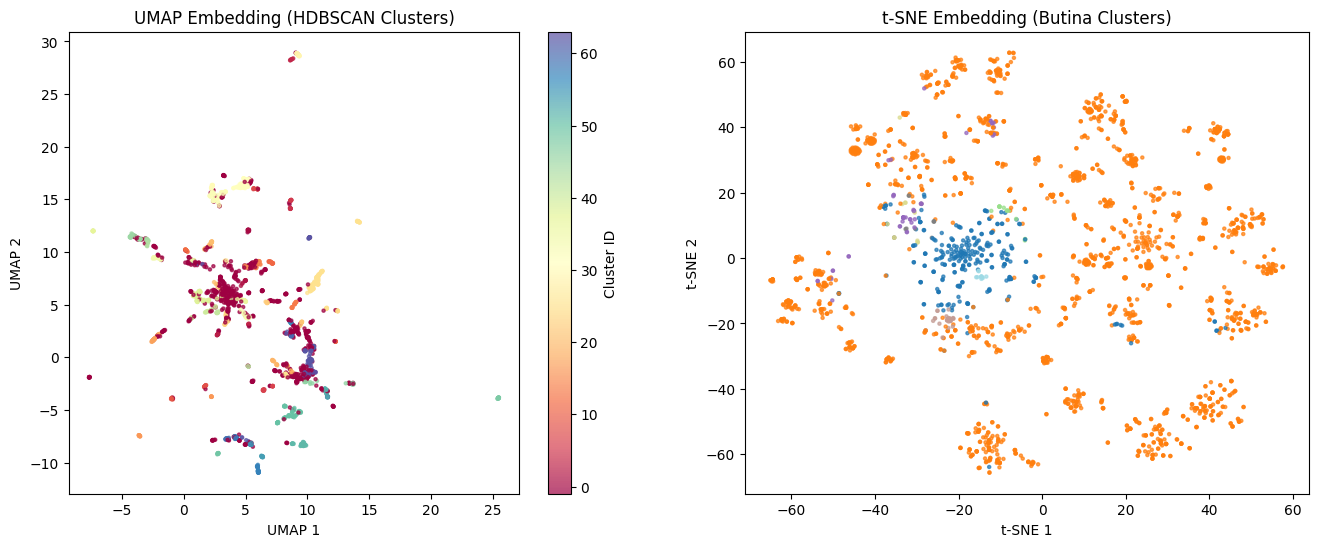

In [25]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = ax1.scatter(umap_embedding[:, 0], umap_embedding[:, 1], 
                       c=hdbs_labels, cmap='Spectral', s=5, alpha=0.7)
ax1.set_title("UMAP Embedding (HDBSCAN Clusters)")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")

scatter2 = ax2.scatter(tsne_embedding[:, 0], tsne_embedding[:, 1], 
                       c=butina_labels, cmap='tab20', s=5, alpha=0.7)
ax2.set_title("t-SNE Embedding (Butina Clusters)")
ax2.set_xlabel("t-SNE 1")
ax2.set_ylabel("t-SNE 2")

plt.colorbar(scatter1, ax=ax1, label='Cluster ID')
plt.show()

Visualise representative molecules of the three biggest clusters of both methods.

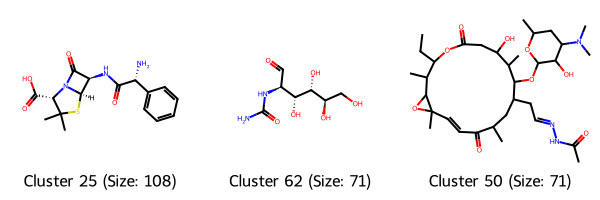

In [26]:
def draw_top_clusters(df, labels):
    unique_labels, counts = np.unique(labels[labels != -1], return_counts=True)
    top_3_indices = np.argsort(counts)[-3:][::-1]
    top_3_labels = unique_labels[top_3_indices]
    
    mols_to_draw = []
    legends = []
    
    for label in top_3_labels:
        # Get the first index belonging to this cluster
        idx = np.where(labels == label)[0][0]
        smiles = df.iloc[idx]['clean_smiles']
        mols_to_draw.append(Chem.MolFromSmiles(smiles))
        legends.append(f"Cluster {label} (Size: {counts[np.where(unique_labels == label)[0][0]]})")
        
    return Draw.MolsToGridImage(mols_to_draw, molsPerRow=3, legends=legends)

draw_top_clusters(df_pubchem, hdbs_labels)

## Discussion points
1) What are the characteristics of the chemical spaces described in the two dataset? What is the difference?
ChEMBL covers a larger chemical space -> randomly sampled drug-like molecules with 200 < M < 500 g/mol, which leads to high structural and chemical diversity
PubChem antibiotics dataset is more structurally and chemically constrained, as antibiotics often share more structural motifs

2) How do density-based clustering techniques compare to models based on similarity in light of the differences in the datasets?
Butina clustering is based on pairwise similarity, which works well when molecules share scaffolds -> works well for PubChem dataset
HDBSCAN is a density-based clustering and automatically detects cluster shapes and can label outliers as noise -> ideally for diverse ChEMBL dataset, as clusters have irregular shapes

3) What were the best model parameters for the clustering techniques (i.e. that delivered a meaningful result)
Butina: cutoff around 0.4 -> decrease in cutoff leads to more clusters
HDBSCAN: min_cluster_size = 10 and min_samples = 2

4) Comment on the different dimensionality reduction techniques (again in light of the different dataset characteristics)
UMAP: preserves both global and local structure; faster than TSNE; produces clearer cluster separation
TSNE: very good for local structure; tends to distort global relationships; slower for large datasets

5) What was the best / most meaningful combination of dimensionality reduction and clustering methods?
ChEMBL forms many small clusters, as a result of the high chemical and structural diversity, contrary to the PubChem dataset
-> HDBSCAN detects noise and irregular cluster shapes
-> Butina gives chemically interpretable similarity clusters

6) Comment on some cheminformatics modelling challenges you may have encountered (e.g. runtime, singleton clusters, paramtersensitivity). What could be done to work around a large number of clusters of small size?

Possible work around: increase the min_cluster_size threshold or apply a broader similarity cutoff/filter to group loose analogs together

7) On the antibiotics dataset, can you identify some known antibiotic classes / motives in your clusters?
beta-Lactams (Penicillins/Cephalosporins); tetracyclines; macrolides; aminoglycosides